In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("statistic_store_benchmark.csv")
df['throughput'] = df['num_statistics'] / (df['duration_ms'] / 1000)

# All possible benchmark parameters (excluding benchmark, store_type, repetition, duration_ms)
ALL_PARAMS = ['num_threads', 'num_statistics', 'num_statistic_ids', 'statistic_size',
              'window_size', 'pct_access_existing', 'pct_insert', 'num_statistics_per_request', 'pct_pre_populate']

df

,benchmark,store_type,num_threads,num_statistics,num_statistic_ids,statistic_size,window_size,pct_access_existing,num_statistics_per_request,pct_insert,pct_pre_populate,random_seed,repetition,duration_ms,throughput
0,InsertStatistic,WINDOW,1,10000000,1,1024,60000,-1,-1,-1,-1,4127551581,0,1345.230,7.433673e+06
1,InsertStatistic,WINDOW,1,10000000,1,1024,60000,-1,-1,-1,-1,4127551581,1,623.879,1.602875e+07
2,InsertStatistic,WINDOW,1,10000000,1,1024,60000,-1,-1,-1,-1,4127551581,2,629.391,1.588837e+07
3,InsertStatistic,WINDOW,4,10000000,1,1024,60000,-1,-1,-1,-1,4127551581,0,2074.480,4.820485e+06
4,InsertStatistic,WINDOW,4,10000000,1,1024,60000,-1,-1,-1,-1,4127551581,1,1481.150,6.751511e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,InsertStatistic,SUB_STORES,4,10000000,1000,1024,60000,-1,-1,-1,-1,4127551581,1,459.234,2.177539e+07
68,InsertStatistic,SUB_STORES,4,10000000,1000,1024,60000,-1,-1,-1,-1,4127551581,2,470.831,2.123904e+07
69,InsertStatistic,SUB_STORES,16,10000000,1000,1024,60000,-1,-1,-1,-1,4127551581,0,284.071,3.520247e+07
70,InsertStatistic,SUB_STORES,16,10000000,1000,1024,60000,-1,-1,-1,-1,4127551581,1,225.295,4.438625e+07


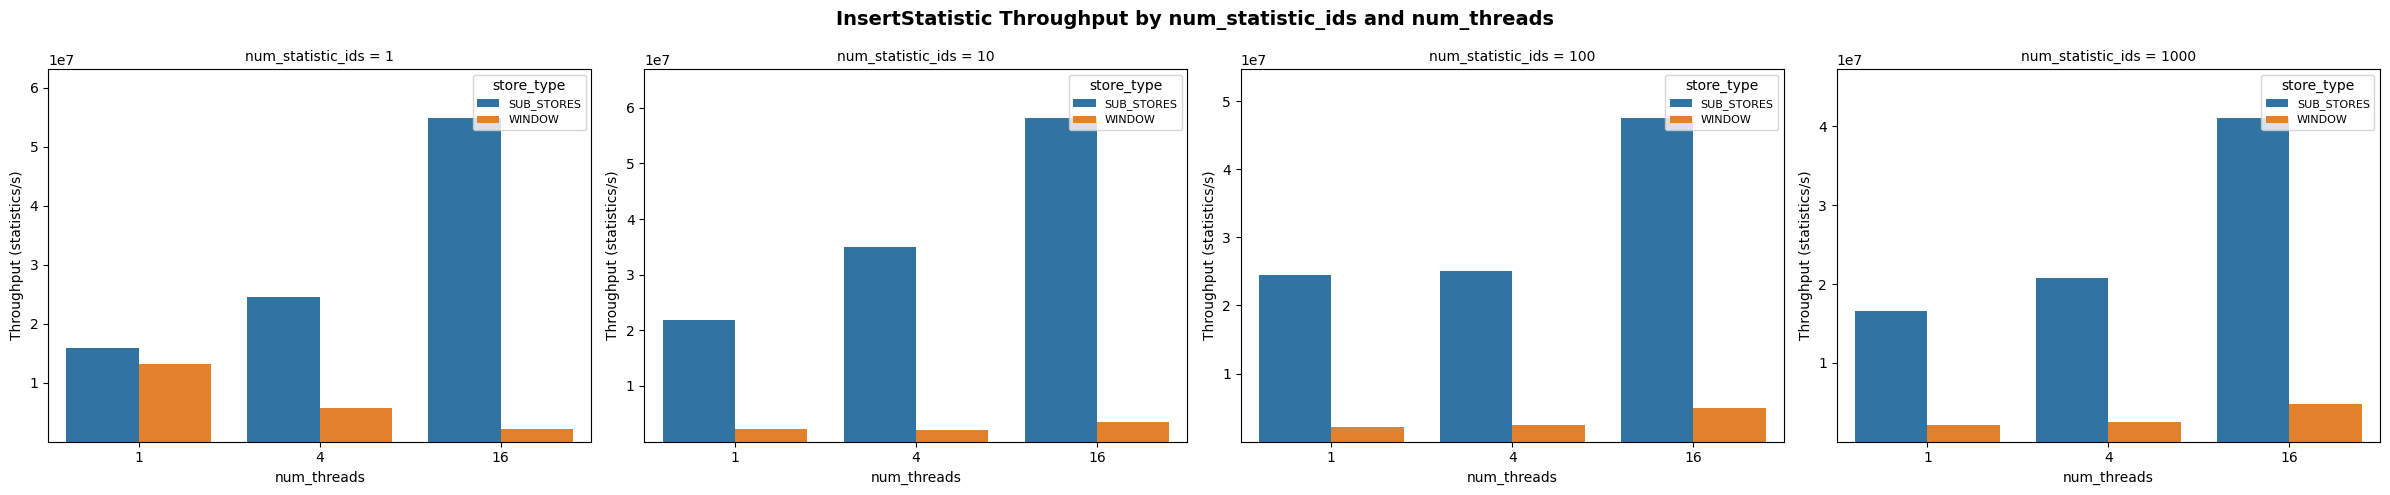

In [2]:
df_bm = df[df['benchmark'] == 'InsertStatistic'].copy()

relevant = [p for p in ALL_PARAMS if not (df_bm[p] == -1).all()]
varying = [p for p in relevant if df_bm[p].nunique() > 1]
fixed = [p for p in relevant if p not in varying]

group_cols = ['store_type', 'num_statistic_ids', 'num_threads']
df_avg = df_bm.groupby(group_cols, as_index=False)[['throughput']].mean()
df_std = df_bm.groupby(group_cols, as_index=False)[['throughput']].std()

# Merge mean and std for error bars
df_plot = pd.merge(df_avg, df_std, on=group_cols, suffixes=('_mean', '_std'))

# Get unique values for num_statistic_ids
num_statistic_ids_values = sorted(df_plot['num_statistic_ids'].unique())
n = len(num_statistic_ids_values)

# Create a figure with subplots for each num_statistic_ids value
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)

for i, num_stat in enumerate(num_statistic_ids_values):
    # Filter data for the current num_statistic_ids value
    subset = df_plot[df_plot['num_statistic_ids'] == num_stat]

    # Calculate the maximum throughput for this subset
    max_throughput = subset['throughput_mean'].max()
    y_max = 1.15 * max_throughput

    # Plot throughput vs. num_threads as bars with error bars
    ax = axes[0][i]
    sns.barplot(
        data=subset,
        x='num_threads',
        y='throughput_mean',
        hue='store_type',
        ax=ax,
        capsize=0.1,
        err_kws={'linewidth': 1.5},
    )
    #ax.set_yscale('log')
    ax.set_ylim(bottom=1, top=y_max)  # Set y-axis limits
    ax.set_xlabel('num_threads')
    ax.set_ylabel('Throughput (statistics/s)')
    ax.set_title(f'num_statistic_ids = {num_stat}', fontsize=10)
    ax.legend(title='store_type', fontsize=8, loc='upper right')

fig.suptitle('InsertStatistic Throughput by num_statistic_ids and num_threads', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("InsertStatistic_Throughput_Bars_WithErrorBars.pdf", dpi=300, bbox_inches="tight")
plt.show()

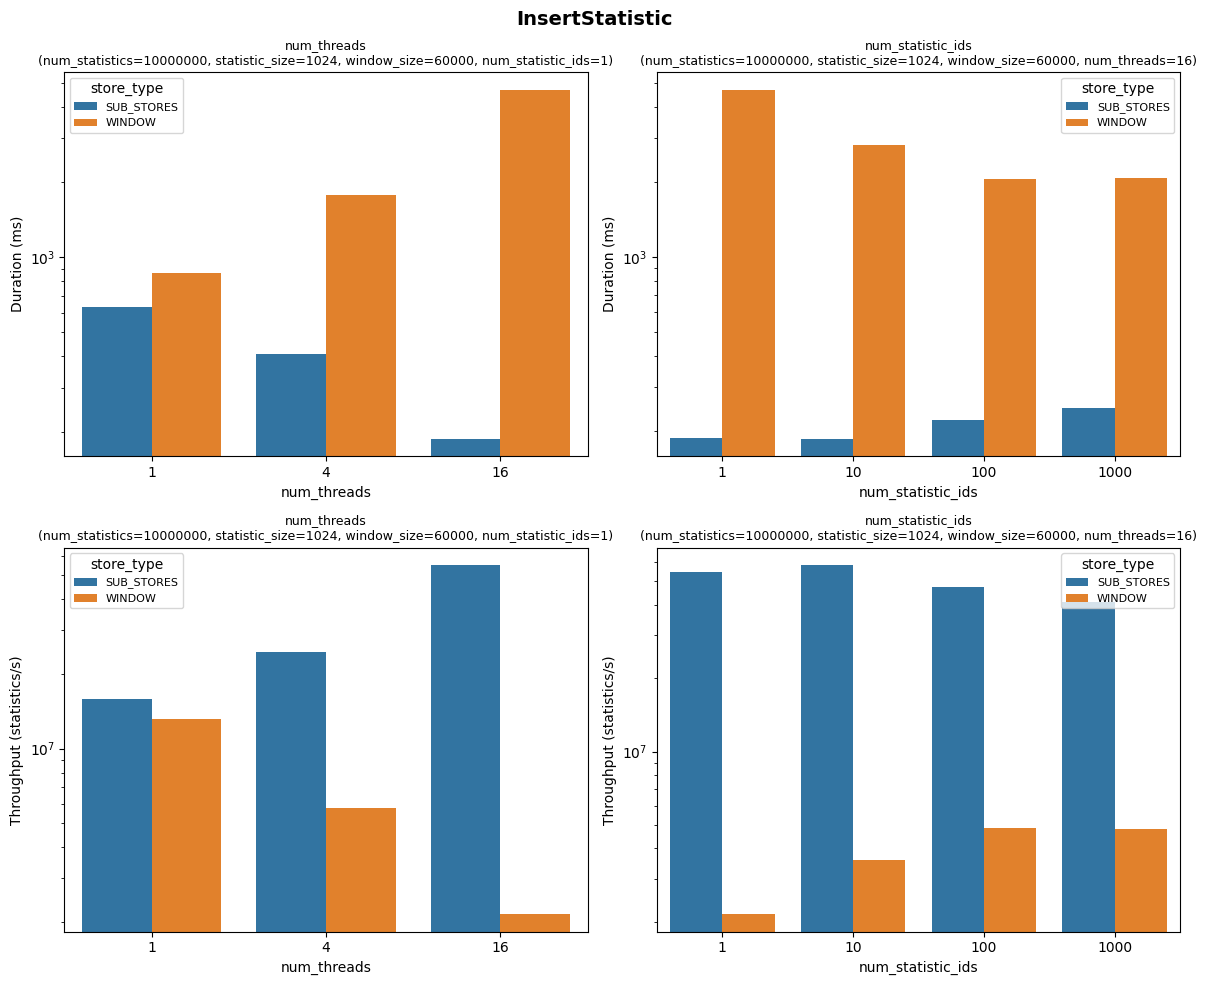

In [3]:
# InsertStatistic
# Override pinned values for 'other varying' parameters.
# By default the mode (most frequent value) is used; add entries here to override.
PIN_VALUES = {
    'num_threads': 16,
}

df_bm = df[df['benchmark'] == 'InsertStatistic'].copy()

relevant = [p for p in ALL_PARAMS if not (df_bm[p] == -1).all()]
varying = [p for p in relevant if df_bm[p].nunique() > 1]
fixed = [p for p in relevant if p not in varying]

group_cols = ['store_type'] + relevant
df_avg = df_bm.groupby(group_cols, as_index=False)[['duration_ms', 'throughput']].mean()

n = len(varying)
fig, axes = plt.subplots(2, n, figsize=(6 * n, 10), squeeze=False)

for i, param in enumerate(varying):
    other_varying = [v for v in varying if v != param]
    subset = df_avg.copy()
    for ov in other_varying:
        pin_val = PIN_VALUES.get(ov, subset[ov].mode().iloc[0])
        subset = subset[subset[ov] == pin_val]

    fixed_info = ', '.join(f'{f}={df_bm[f].iloc[0]}' for f in fixed)
    other_info = ', '.join(f'{ov}={subset[ov].iloc[0]}' for ov in other_varying)
    subtitle_parts = [s for s in [fixed_info, other_info] if s]
    subtitle = f'\n({", ".join(subtitle_parts)})' if subtitle_parts else ''

    # Duration
    ax = axes[0][i]
    sns.barplot(data=subset, x=param, y='duration_ms', hue='store_type', ax=ax)
    ax.set_yscale('log')
    ax.set_xlabel(param)
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'{param}{subtitle}', fontsize=9)
    ax.legend(title='store_type', fontsize=8)

    # Throughput
    ax = axes[1][i]
    sns.barplot(data=subset, x=param, y='throughput', hue='store_type', ax=ax)
    ax.set_yscale('log')
    ax.set_xlabel(param)
    ax.set_ylabel('Throughput (statistics/s)')
    ax.set_title(f'{param}{subtitle}', fontsize=9)
    ax.legend(title='store_type', fontsize=8)

fig.suptitle('InsertStatistic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("InsertStatistic.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
import textwrap

# All other benchmarks (linear y-axis)
for benchmark_name, df_bm in df[df['benchmark'] != 'InsertStatistic'].groupby('benchmark'):
    df_bm = df_bm.copy()

    relevant = [p for p in ALL_PARAMS if not (df_bm[p] == -1).all()]
    varying = [p for p in relevant if df_bm[p].nunique() > 1]
    fixed = [p for p in relevant if p not in varying]

    if not varying:
        print(f"Skipping {benchmark_name}: no varying parameters")
        continue

    group_cols = ['store_type'] + relevant
    df_avg = df_bm.groupby(group_cols, as_index=False)[['duration_ms', 'throughput']].mean()

    n = len(varying)
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 10), squeeze=False)

    for i, param in enumerate(varying):
        other_varying = [v for v in varying if v != param]
        subset = df_avg.copy()
        for ov in other_varying:
            mode_val = subset[ov].mode().iloc[0]
            subset = subset[subset[ov] == mode_val]

        fixed_info = ', '.join(f'{f}={df_bm[f].iloc[0]}' for f in fixed)
        other_info = ', '.join(f'{ov}={subset[ov].iloc[0]}' for ov in other_varying)
        subtitle_parts = [s for s in [fixed_info, other_info] if s]
        if subtitle_parts:
            wrapped = textwrap.fill(', '.join(subtitle_parts), width=40)
            subtitle = f'\n({wrapped})'
        else:
            subtitle = ''

        # Duration
        ax = axes[0][i]
        sns.barplot(data=subset, x=param, y='duration_ms', hue='store_type', ax=ax)
        ax.set_xlabel(param)
        ax.set_yscale('log')
        ax.set_ylabel('Duration (ms)')
        ax.set_title(f'{param}{subtitle}', fontsize=9)
        ax.legend(title='store_type', fontsize=8)

        # Throughput
        ax = axes[1][i]
        sns.barplot(data=subset, x=param, y='throughput', hue='store_type', ax=ax)
        ax.set_xlabel(param)
        ax.set_ylabel('Throughput (statistics/s)')
        ax.set_title(f'{param}{subtitle}', fontsize=9)
        ax.legend(title='store_type', fontsize=8)

    fig.suptitle(benchmark_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{benchmark_name}.pdf", dpi=300, bbox_inches="tight")
    plt.show()